Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

Updates: 
1. ER_3 eliminated for bad fits. 
2. LH_3 eliminated for bad fits. 
3. LH_2 eliminated for bad fits. 
4. ER_2 looks good. 
5. ER_2_3: KO rhat
6. ER_LH_2: KO divergences
7. ER_LH_2_3: KO rhat (+ divergences rate)

# Initialization - KO only 

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

plt.rcParams['figure.dpi'] = 60
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 298.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)
E_obs = experiments_interp[(0.1, 0.1)]['E'] # V vs SHE - random conditions

alpha_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
alpha_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        alpha_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha']
        alpha_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha_SD']

delta_OH_obs = np.zeros((len(P_CO_list), len(E_obs)))
delta_OH_obs_SD = np.zeros((len(P_CO_list), len(E_obs)))
for j, P_CO in enumerate(P_CO_list):
    delta_OH_obs[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH'] # Random C_KOH
    delta_OH_obs_SD[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH_SD']

delta_CO_obs = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
delta_CO_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list[:-1]): 
        delta_CO_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO']
        delta_CO_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO_SD']

log_rate_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
log_rate_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        log_rate_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['log_rate']
        log_rate_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['log_rate_SD']

# Constructing variables to make it more feasible for models
# Variables reshaped for broadcasting
dE = E_obs[1] - E_obs[0]
d_ln_P_CO = np.diff(np.log(P_CO_list))[None, :, None]

# Need this because np.polyfit doesn't work with pymc variables - used for delta_OH
ln_C = np.log(C_KOH_list)
ln_C_mean = np.mean(ln_C)
S_xx = np.sum((ln_C - ln_C_mean)**2)
w_C = (ln_C - ln_C_mean) / S_xx
w_C_in = w_C[:, None, None]

C_KOH_in = C_KOH_list[:, None, None] # Shape (N, 1, 1)
P_CO_in = P_CO_list[None, :, None] # Shape (1, N, 1)
E_in = E_obs[None, None, :] # Shape (1, 1, N)

def calc_observables(log_rate): 
    '''
    Converts a raw rate tensor (C_KOH, P_CO, E) into kinetic observables (alpha, delta_OH, delta_CO).
    Returns PyTensor variables ready for the model.
    '''
    # Alpha with central difference (forward/backward difference at edges - no points lost)
    d_log_rate_dE = pt.zeros_like(log_rate)
    d_log_rate_center_dE = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2*dE)
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 1:-1], d_log_rate_center_dE)
    d_log_rate_start_dE = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 0], d_log_rate_start_dE)
    d_log_rate_end_dE = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, -1], d_log_rate_end_dE)
    mu_alpha = (R*T/F) * d_log_rate_dE

    # Delta OH with linear regression: weights set up earlier
    mu_delta_OH = pt.sum(w_C_in * log_rate, axis=0)

    # Delta CO with finite difference, losing a P_CO point
    d_log_rate_P = log_rate[:, 1:, :] - log_rate[:, :-1, :]
    mu_delta_CO = d_log_rate_P / d_ln_P_CO

    return mu_alpha, mu_delta_OH, mu_delta_CO

def get_combined_loo(idata):
    """
    Merges multiple log-likelihood variables into a single array 
    and calculates the global LOO score, preserving the posterior for Reff.
    """
    ll_list = []
    for var_name in idata.log_likelihood.data_vars:
        da = idata.log_likelihood[var_name]
        obs_dims = [d for d in da.dims if d not in ('chain', 'draw')]
        if obs_dims: da_flat = da.stack(observations=obs_dims)
        else: da_flat = da.expand_dims(observations=1) 
        da_flat = da_flat.reset_index('observations', drop=True)
        ll_list.append(da_flat)

    combined_ll = xr.concat(ll_list, dim='observations')
    combined_ll = combined_ll.assign_coords(observations=range(combined_ll.sizes['observations']))
    new_idata = az.InferenceData(posterior=idata.posterior, log_likelihood=combined_ll.to_dataset(name='total_model')) 
    return az.loo(new_idata, var_name='total_model', pointwise=True)

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    y_true_flat = y_true.flatten()
    chains, draws = y_pred.shape[:2]
    y_pred_flat = y_pred.reshape(chains * draws, -1)
    r2 = az.r2_score(y_true_flat, y_pred_flat)
    return r2['r2']

In [ ]:
def plot_posteriors(trace, model, target='word'): 
    all_vars = list(trace.posterior.data_vars)
    excluded_vars = ['alpha', 'delta_OH', 'delta_CO', 'rate_linear', 'log_rate']
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta') and v not in excluded_vars]
    
    num_vars = len(kinetic_vars)
    cols = 4
    rows = 2 # Forced for 7-8 params

    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2})
        figsize_post = (12, 7) 
        figsize_pair = (10, 10)
        title_size = 20
        text_size_adj = 12 # Size of HDI text/labels
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 1.5})
        figsize_post = (10, 6)
        figsize_pair = (8, 8)
        title_size = 14
        text_size_adj = 10

    if kinetic_vars:
        # added textsize to keep HDI labels legible
        axes = az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, 
                          round_to=3, figsize=figsize_post, grid=(rows, cols),
                          textsize=text_size_adj)
        for ax in axes.flatten():
            for text_obj in ax.texts: 
                text_string = text_obj.get_text()
                if 'mean' in text_string:
                    text_obj.set_fontweight('bold')
            ax.title.set_fontweight('bold')
        plt.subplots_adjust(hspace=0.5, top=0.88)
        # plt.suptitle("Kinetic Parameter Posteriors", fontsize=title_size, fontweight='bold')
        plt.show()

    if len(kinetic_vars) > 1:
        az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, 
                     figsize=figsize_pair, textsize=10)
        # plt.suptitle("Parameter Correlations", fontsize=title_size, fontweight='bold')
        plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)
    
    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")

    plt.rcParams.update(plt.rcParamsDefault)    
    return ppc

def plot_model_fits(trace, ppc, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize_4x4 = (12, 11)   # Reduced height to stop vertical stretching
        figsize_3x4 = (12, 8.5)  
        figsize_1x4 = (12, 4)   
        title_size, label_size = 18, 14
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize_4x4 = (7.5, 7)
        figsize_3x4 = (7.5, 5.5)
        figsize_1x4 = (7.5, 2.5)
        title_size, label_size = 12, 10

    colors = plt.cm.tab10.colors[:len(P_CO_list)]

    def get_model_data(var_name_fit, var_name_track):
        if var_name_fit in ppc.posterior_predictive.data_vars:
            return ppc.posterior_predictive[var_name_fit], False 
        else:
            return trace.posterior[var_name_track], True 

    def plot_grid(var_fit, var_track, nrows, ncols, figsize, ylabel, title_text, is_3x4=False, is_1x4=False):
        model_data_xr, is_det = get_model_data(var_fit, var_track)
        
        # sharey=False for linear rate to avoid disappearing low-pressure lines
        share_y = False if var_fit == 'rate_linear' else True
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True, sharey=share_y)
        fig.suptitle(title_text, fontsize=title_size, fontweight='bold', y=0.97)

        for i, C_KOH in enumerate(C_KOH_list):
            for j, P_CO in enumerate(P_CO_list):
                if is_1x4: 
                    if i > 0: continue
                    ax = axes[j]
                    cond_key = (0.1, P_CO)
                elif is_3x4:
                    if j >= 3: continue
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO_list[j])
                else:
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO)

                E_exp = experiments_interp[cond_key]['E']
                col_map = {'rate':'log_rate', 'rate_linear':'rate', 'alpha':'alpha', 'delta_OH':'delta_OH', 'delta_CO':'delta_CO'}
                exp_mean = experiments_interp[cond_key][col_map[var_fit]]
                exp_sd = experiments_interp[cond_key][col_map[var_fit]+'_SD']
                
                model_slice = model_data_xr[:, :, i, j, :] if not is_1x4 else model_data_xr[:, :, j, :]
                model_mean = model_slice.mean(dim=("chain", "draw"))
                hdi_95 = az.hdi(model_slice, hdi_prob=0.95)[model_slice.name]
                hdi_90 = az.hdi(model_slice, hdi_prob=0.90)[model_slice.name]

                if is_det:
                    ax.fill_between(E_exp, exp_mean - exp_sd, exp_mean + exp_sd, color='gray', alpha=0.3, linewidth=0, zorder=1)
                ax.plot(E_exp, exp_mean, color='black', lw=2.5, alpha=0.6, zorder=2)

                # Model HDI
                ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, zorder=3)
                ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.30, linewidth=0, zorder=4)
                
                # Thicker Model Mean Line
                ax.plot(E_exp, model_mean, color=colors[j], lw=3.2, zorder=5)

                if j == 0 and not is_1x4: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
                if is_1x4: ax.set_title(f'{P_CO} atm', fontsize=label_size, fontweight='bold')
                
                if i == 3 and not is_1x4:
                    label_right = f'{P_CO} atm' if not is_3x4 else f'{P_CO_list[j]}-{P_CO_list[j+1]} atm'
                    ax.text(1.05, 0.5, label_right, transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
                
                if is_1x4:
                    # For 1x4: j is the column, so we want x-labels everywhere, and y-label only on column 0
                    ax.set_xlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold')
                    if j == 0: ax.set_ylabel(ylabel, fontweight='bold')
                else:
                    # For 2D grids: j is the row, i is the column
                    if j == (nrows-1): ax.set_xlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold')
                    if i == 0: ax.set_ylabel(ylabel, fontweight='bold')

        # Increased top margin for OH Reaction order to prevent title mushing
        top_adj = 0.85 if is_1x4 else 0.91
        plt.tight_layout(); plt.subplots_adjust(right=0.92, top=top_adj); plt.show()

    # plot_grid('rate', 'log_rate', 4, 4, figsize_4x4, "log Rate", "Log Rate")
    # plot_grid('rate_linear', 'rate_linear', 4, 4, figsize_4x4, "Rate", "Linear Rate")
    plot_grid('alpha', 'alpha', 4, 4, figsize_4x4, "alpha", "Transfer Coefficients")
    plot_grid('delta_OH', 'delta_OH', 1, 4, figsize_1x4, "Order (OH)", "OH Reaction Order", is_1x4=True)
    plot_grid('delta_CO', 'delta_CO', 3, 4, figsize_3x4, "Order (CO)", "CO Reaction Order", is_3x4=True)
    plt.rcParams.update(plt.rcParamsDefault)

def plot_coverages(trace, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize = (12, 11) # Shorter height
        title_size, label_size = 20, 16
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize = (7.5, 6.5)
        title_size, label_size = 12, 10

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle('Modeled Surface Coverages', fontsize=title_size, fontweight='bold', y=0.97)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']

            for var, col, lab in zip(['theta_CO', 'theta_OH', 'theta_COOH'], 
                                     ['tab:red', 'tab:blue', 'tab:green'], 
                                     [r'$\theta_{CO}$', r'$\theta_{OH}$', r'$\theta_{COOH}$']):
                if var in trace.posterior:
                    data = trace.posterior[var][:, :, i, j, :]
                    mu = data.mean(dim=("chain", "draw"))
                    hdi = az.hdi(data, hdi_prob=0.95)[var]
                    ax.fill_between(E_exp, hdi[:, 0], hdi[:, 1], color=col, alpha=0.15, linewidth=0)
                    ax.plot(E_exp, mu, color=col, label=lab, lw=2.5)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
            if j == 3: ax.set_xlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold')
            if i == 0: ax.set_ylabel("Coverage", fontweight='bold')        
            if i == 0 and j == 0: ax.legend(loc='upper right', frameon=False, fontsize=10)

    plt.tight_layout(); plt.subplots_adjust(right=0.92, top=0.91); plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

In [3]:
def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.99):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = get_combined_loo(trace)
    print(loo)
    az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    return trace, loo

def observables(log_rate): 
    mu_alpha, mu_delta_OH, mu_delta_CO = calc_observables(log_rate)
    alpha = pm.StudentT('alpha', nu=3, mu=mu_alpha, sigma=alpha_obs_SD, observed=alpha_obs)
    delta_OH = pm.StudentT('delta_OH', nu=3, mu=mu_delta_OH, sigma=delta_OH_obs_SD, observed=delta_OH_obs)
    delta_CO = pm.StudentT('delta_CO', nu=3, mu=mu_delta_CO, sigma=delta_CO_obs_SD, observed=delta_CO_obs)
    return alpha, delta_OH, delta_CO

In [4]:
# Helper functions 

def quadratic_solve(a, b, c): 
    max_val = pt.maximum(pt.abs(a), pt.maximum(pt.abs(b), pt.abs(c)))
    a_n = a / max_val; b_n = b / max_val; c_n = c / max_val
    discriminant = pt.sqr(b_n) - 4 * a_n *c_n
    sqrt_disc = pt.sqrt(discriminant)
    root_pos = -2 * c_n / (b_n + sqrt_disc)
    root_neg = (sqrt_disc - b_n) / (2 * a_n)
    return pt.switch(pt.gt(b_n, 0), root_pos, root_neg)

# LH 2

# ER 2

# ER 3

# LH 3

# ER 2 3 - Series RDS

# ER 2 + LH 2 - Parallel RDS

# ER 2 + LH 2 + 3 - Prior Set 1

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,127
,3000,0,0.05,63
,3000,0,0.08,63
,3000,0,0.06,191


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -72.11   103.84
p_loo       20.25        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3177   99.3%
   (0.70, 1]   (bad)         5    0.2%
   (1, Inf)   (very bad)   18    0.6%



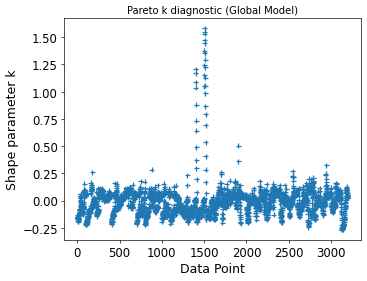

In [5]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd and 3rd steps are RDS
with pm.Model() as ER_LH_2_3_Prior1:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    2b. CO* + OH* -> COOH* + * (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.2, upper=-0.1) 
    # deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.05, upper=0.05) # at 0V_SHE
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.3, upper=-0.2) # at 0V_SHE
    deltaG2_LH_0 = pm.Uniform('deltaG2_LH_0', lower=-2, upper=0.1) # at 0V_SHE
    deltaG2_ER_0 = deltaG2_LH_0 + deltaG4_0 # Hess' law
    beta_2 = pm.Uniform("beta_2", lower=0, upper=1)
    beta_3 = pm.Uniform("beta_3", lower=0, upper=1)
    Gact2_LH_0 = pm.Uniform('Gact2_LH_0', lower=-0.5, upper=0.75) # at 0V_SHE
    Gact2_ER_0 = 0 # Fixed at 0 eV
    Gact3_0 = pm.Uniform('Gact3_0', lower=-1, upper=0.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_LH_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    log_C_KOH = np.log(C_KOH_in)
    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + log_C_KOH

    zeros = pt.zeros_like(term_CO+term_OH)
    log_Z = pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_k2a_fwd = log_k2_ER + log_C_KOH; log_k2b_fwd = log_k2_LH
    log_k2a_rev = log_k2_ER - log_K2_ER; log_k2b_rev = log_k2_LH - log_K2_LH
    log_k3_fwd  = log_k3 + log_C_KOH
    log_R_sink = pt.logaddexp(log_k2a_rev, log_k3_fwd); R_sink = pt.exp(log_R_sink)
    log_a_quad = pt.logaddexp(log_k2b_fwd + term_CO + term_OH, log_Z + log_k2b_rev); a_quad = pt.exp(log_a_quad)
    b_quad = pt.exp(log_k2a_fwd + term_CO) + pt.exp(log_Z + log_R_sink) - pt.exp(log_k2b_rev)
    c_quad = -R_sink
    theta = quadratic_solve(a_quad, b_quad, c_quad)
    num_COOH = pt.exp(log_k2a_fwd + term_CO) * theta + pt.exp(log_k2b_fwd + term_CO + term_OH) * pt.sqr(theta)
    den_COOH = R_sink + pt.exp(log_k2b_rev) * theta
    theta_COOH = num_COOH / den_COOH

    theta_CO = pm.Deterministic('theta_CO', pt.exp(term_CO) * theta)
    theta_OH = pm.Deterministic('theta_OH', pt.exp(term_OH) * theta)
    theta_COOH = pm.Deterministic('theta_COOH', theta_COOH)

    log_rate = log_k3 + pt.log(theta_COOH) + log_C_KOH
    alpha, delta_OH, delta_CO = observables(log_rate)
        
trace_ER_LH_2_3_Prior1, loo_ER_LH_2_3_Prior1 = fit_and_evaluate(ER_LH_2_3_Prior1)

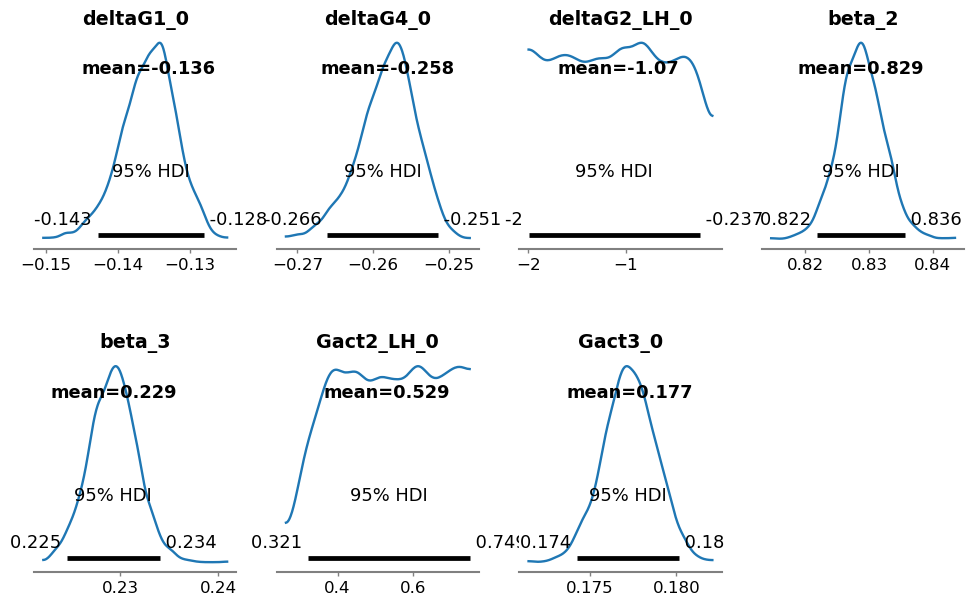

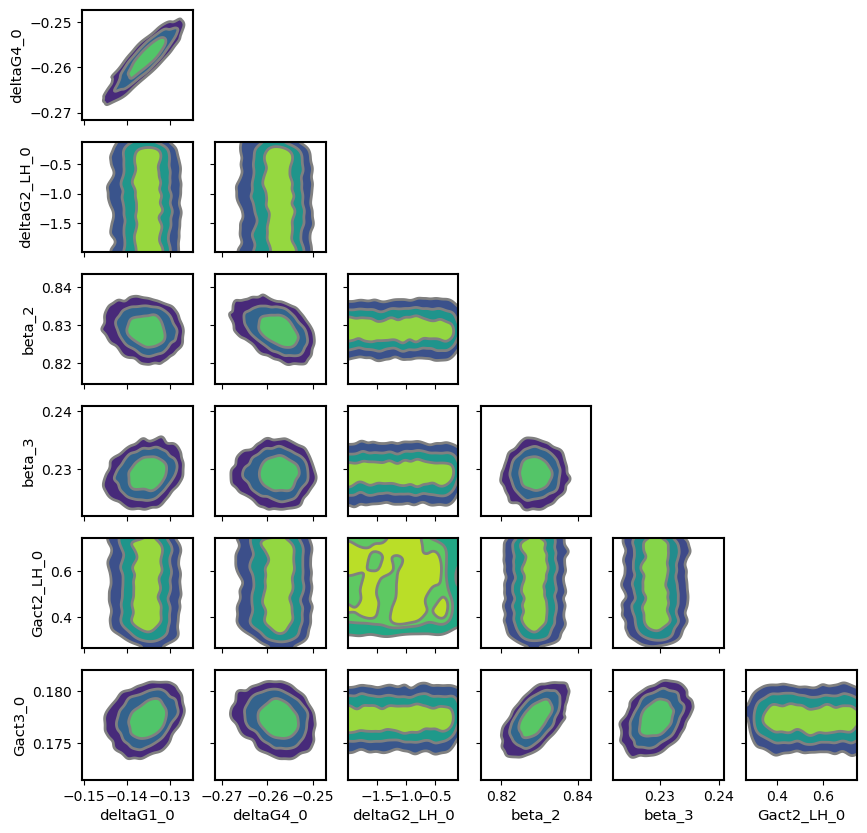

Sampling: [alpha, delta_CO, delta_OH]


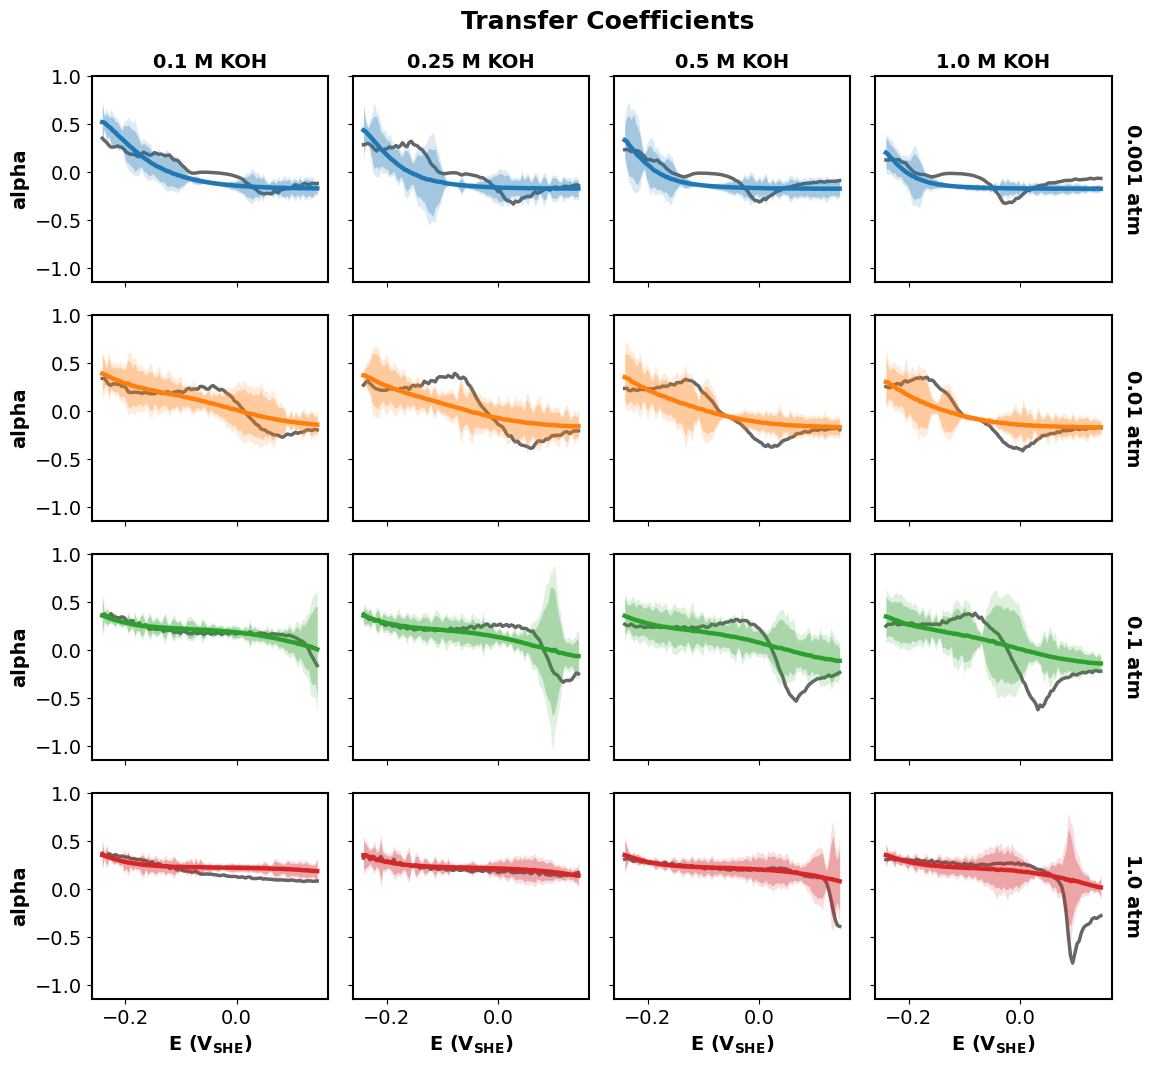

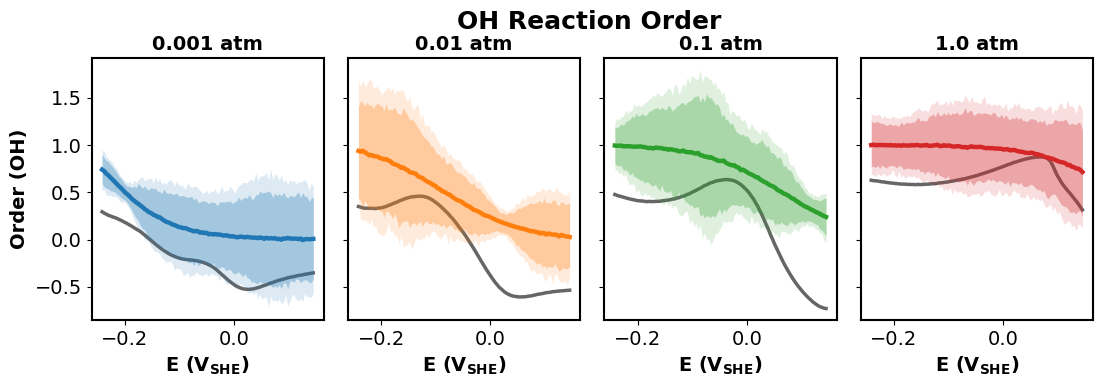

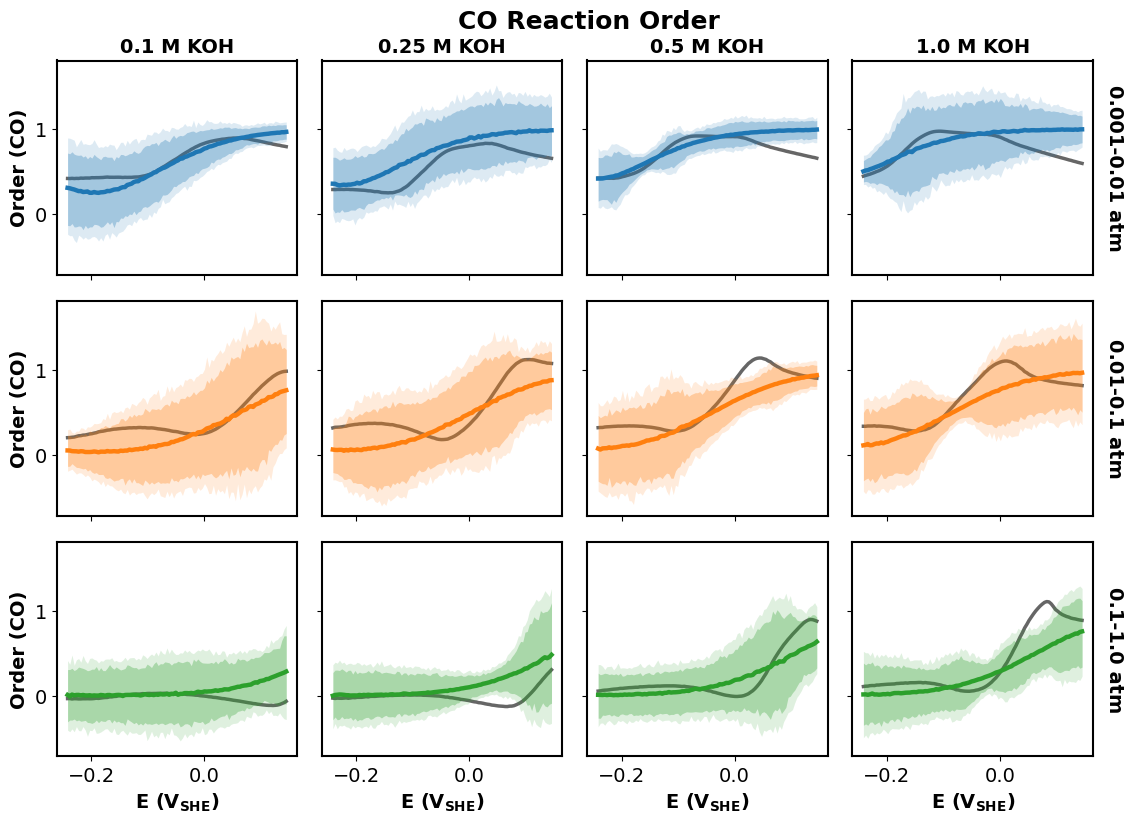

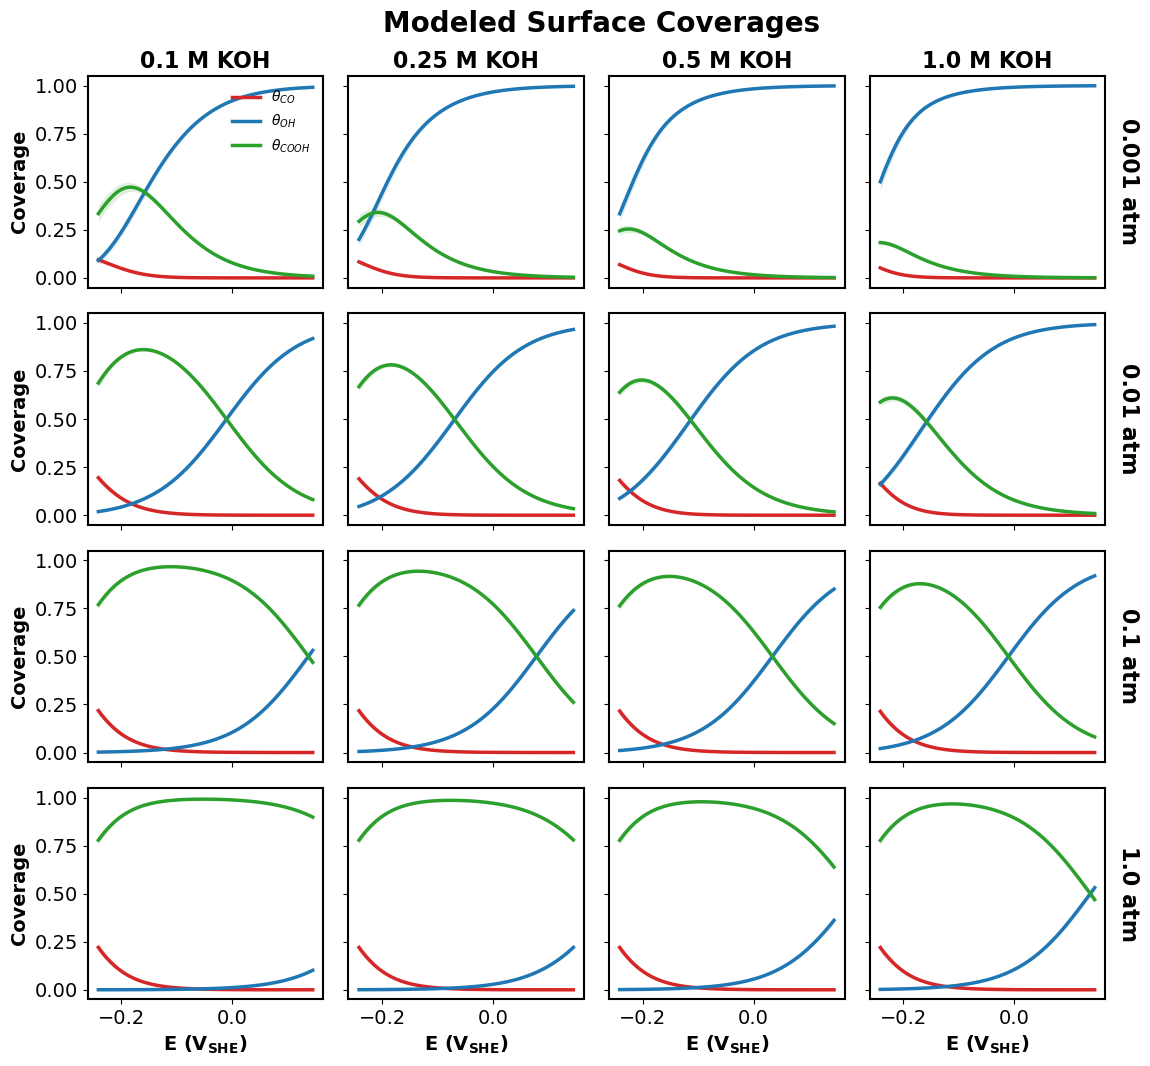

In [18]:
target = 'ppt'
ppc_ER_LH_2_3_Prior1 = plot_posteriors(trace_ER_LH_2_3_Prior1, ER_LH_2_3_Prior1, target)
plot_model_fits(trace_ER_LH_2_3_Prior1, ppc_ER_LH_2_3_Prior1, target); plot_coverages(trace_ER_LH_2_3_Prior1, target)

# ER 2 + LH 2 + 3 - Prior Set 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.20,15
,3000,0,0.18,15
,3000,0,0.04,127
,3000,0,0.20,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3183.35   150.18
p_loo     1575.21        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3186   99.6%
   (0.70, 1]   (bad)         7    0.2%
   (1, Inf)   (very bad)    7    0.2%



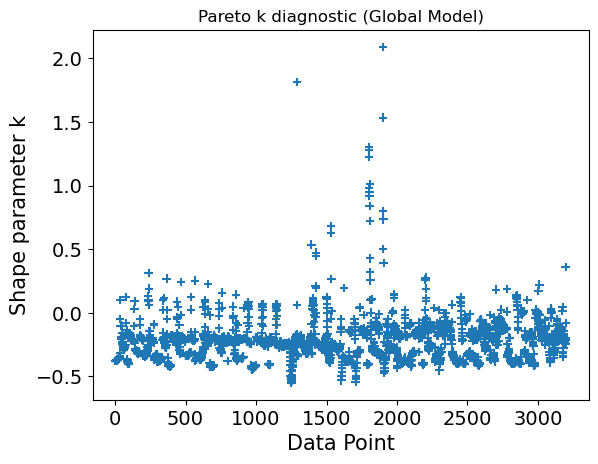

In [9]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd and 3rd steps are RDS
with pm.Model() as ER_LH_2_3_Prior2:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    2b. CO* + OH* -> COOH* + * (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.2, upper=-0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.05, upper=0.05) # at 0V_SHE
    # deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.3, upper=-0.2) # at 0V_SHE
    deltaG2_LH_0 = pm.Uniform('deltaG2_LH_0', lower=-2, upper=0.1) # at 0V_SHE
    deltaG2_ER_0 = deltaG2_LH_0 + deltaG4_0 # Hess' law
    beta_2 = pm.Uniform("beta_2", lower=0, upper=1)
    beta_3 = pm.Uniform("beta_3", lower=0, upper=1)
    Gact2_LH_0 = pm.Uniform('Gact2_LH_0', lower=-0.5, upper=0.75) # at 0V_SHE
    Gact2_ER_0 = 0 # Fixed at 0 eV
    Gact3_0 = pm.Uniform('Gact3_0', lower=-1, upper=0.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_LH_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    log_C_KOH = np.log(C_KOH_in)
    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + log_C_KOH

    zeros = pt.zeros_like(term_CO+term_OH)
    log_Z = pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_k2a_fwd = log_k2_ER + log_C_KOH; log_k2b_fwd = log_k2_LH
    log_k2a_rev = log_k2_ER - log_K2_ER; log_k2b_rev = log_k2_LH - log_K2_LH
    log_k3_fwd  = log_k3 + log_C_KOH
    log_R_sink = pt.logaddexp(log_k2a_rev, log_k3_fwd); R_sink = pt.exp(log_R_sink)
    log_a_quad = pt.logaddexp(log_k2b_fwd + term_CO + term_OH, log_Z + log_k2b_rev); a_quad = pt.exp(log_a_quad)
    b_quad = pt.exp(log_k2a_fwd + term_CO) + pt.exp(log_Z + log_R_sink) - pt.exp(log_k2b_rev)
    c_quad = -R_sink
    theta = quadratic_solve(a_quad, b_quad, c_quad)
    num_COOH = pt.exp(log_k2a_fwd + term_CO) * theta + pt.exp(log_k2b_fwd + term_CO + term_OH) * pt.sqr(theta)
    den_COOH = R_sink + pt.exp(log_k2b_rev) * theta
    theta_COOH = num_COOH / den_COOH

    theta_CO = pm.Deterministic('theta_CO', pt.exp(term_CO) * theta)
    theta_OH = pm.Deterministic('theta_OH', pt.exp(term_OH) * theta)
    theta_COOH = pm.Deterministic('theta_COOH', theta_COOH)

    log_rate = log_k3 + pt.log(theta_COOH) + log_C_KOH
    alpha, delta_OH, delta_CO = observables(log_rate)
        
trace_ER_LH_2_3_Prior2, loo_ER_LH_2_3_Prior2 = fit_and_evaluate(ER_LH_2_3_Prior2)

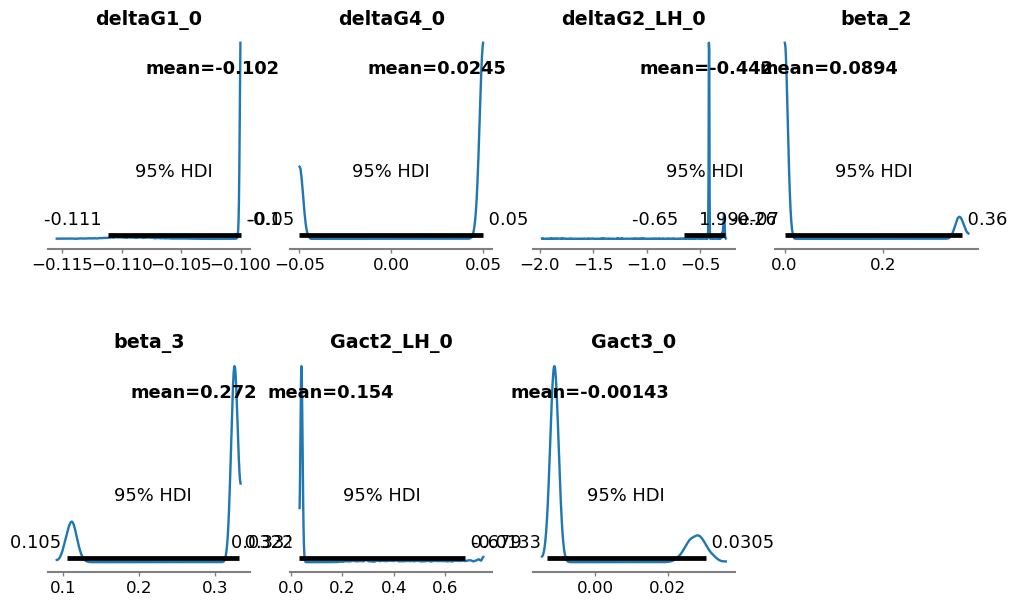

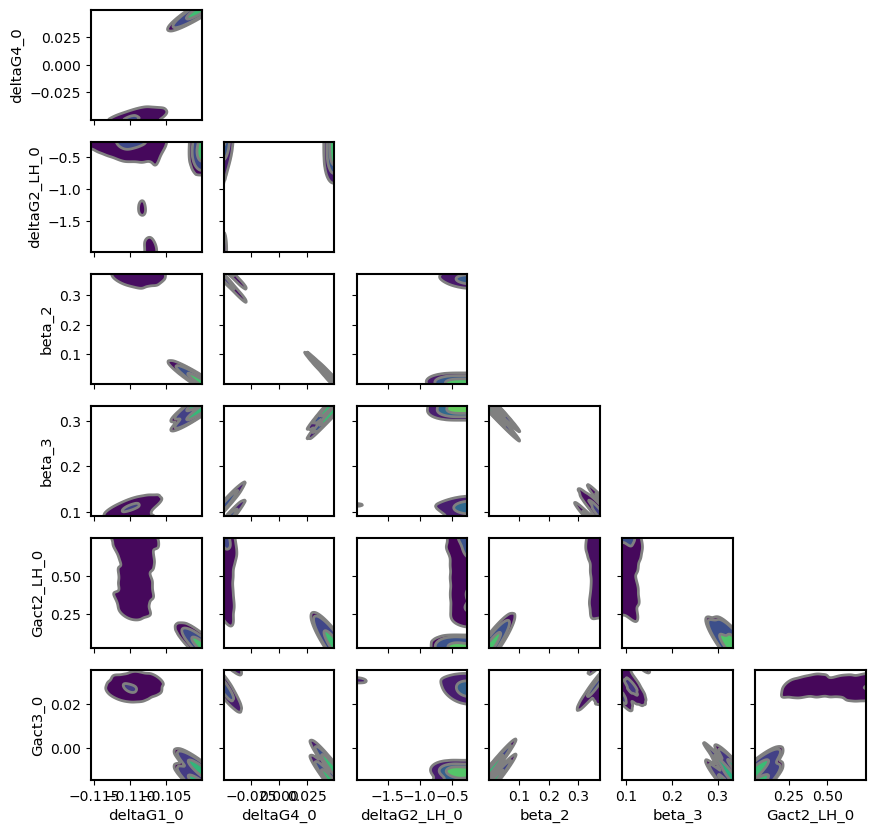

Sampling: [alpha, delta_CO, delta_OH]


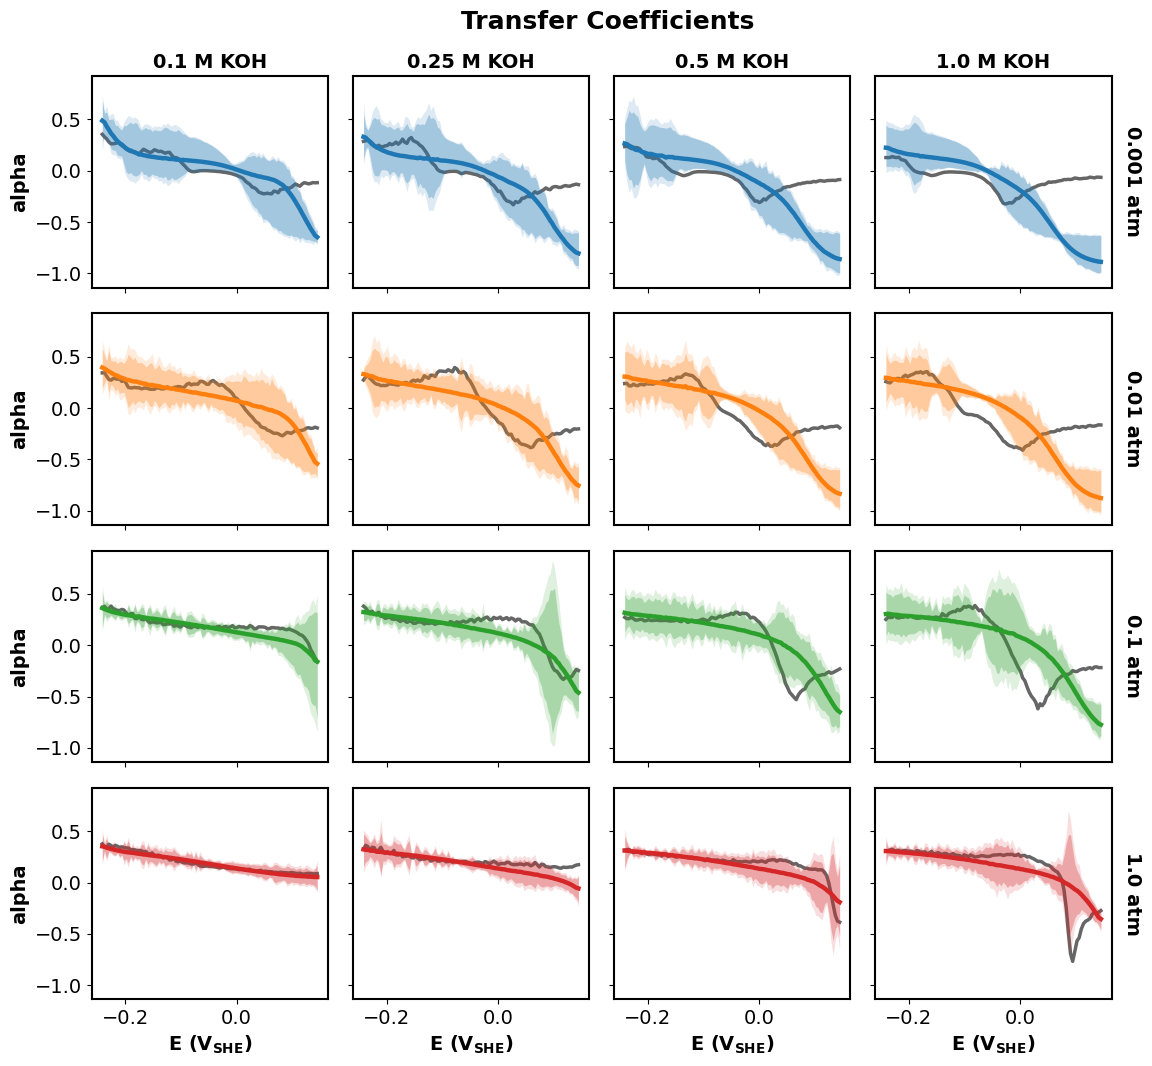

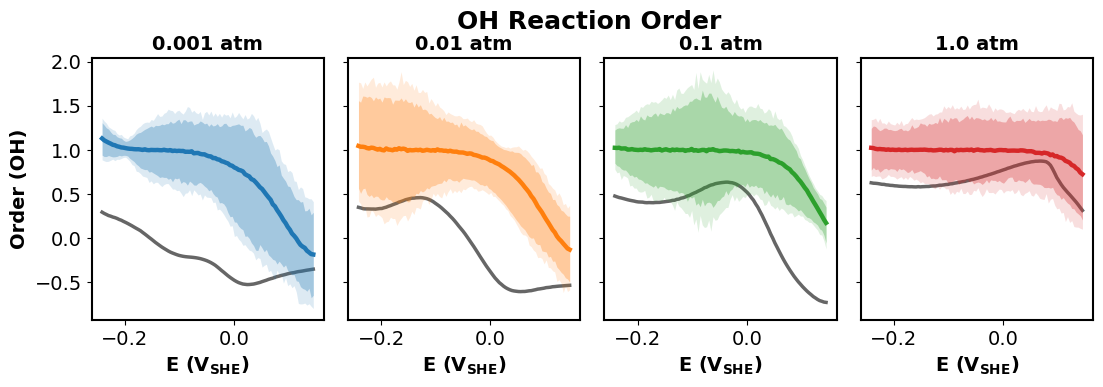

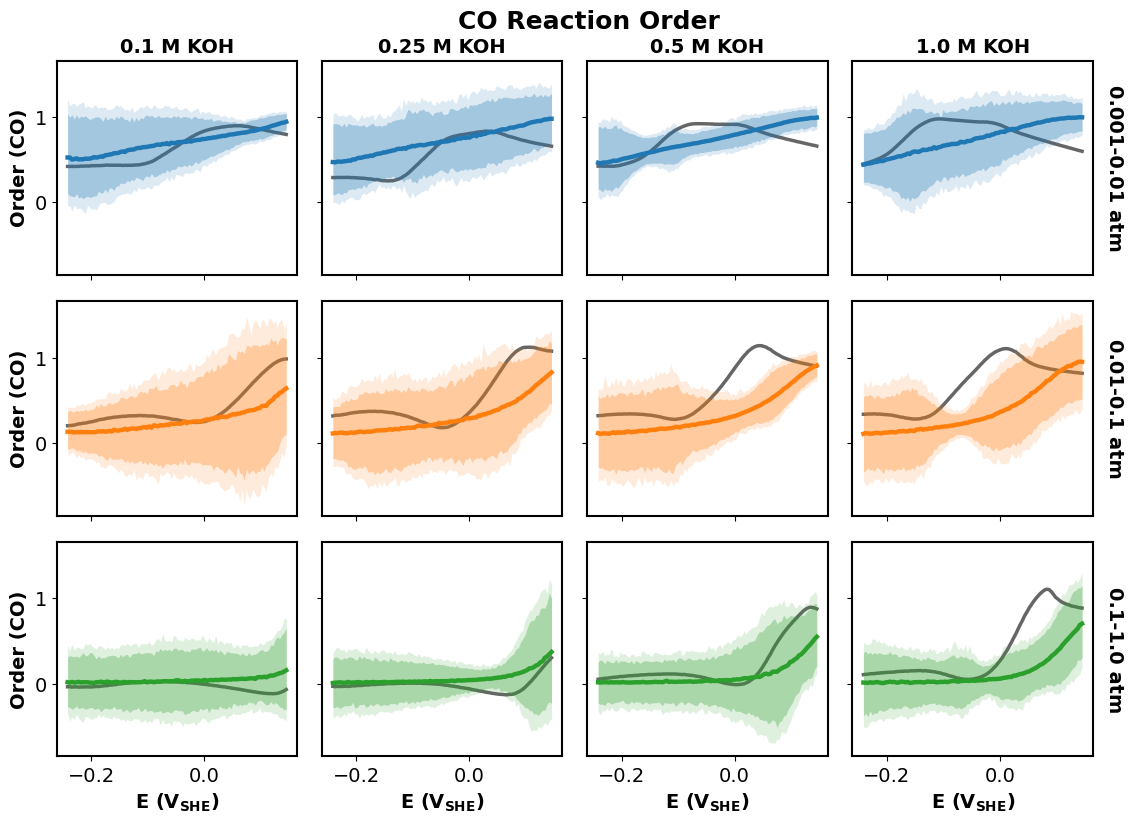

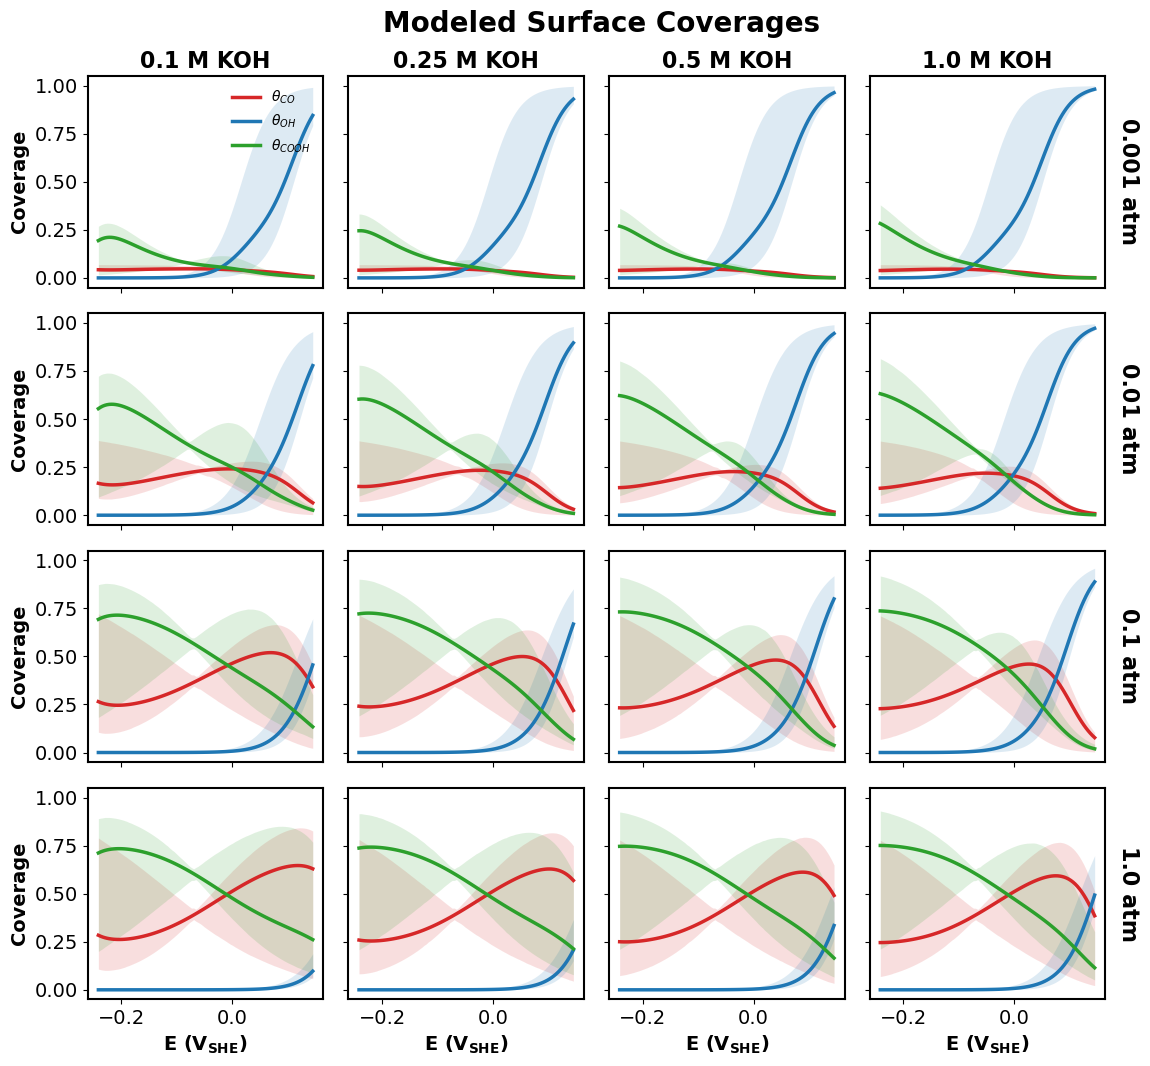

In [19]:
target = 'ppt'
ppc_ER_LH_2_3_Prior2 = plot_posteriors(trace_ER_LH_2_3_Prior2, ER_LH_2_3_Prior2, target)
plot_model_fits(trace_ER_LH_2_3_Prior2, ppc_ER_LH_2_3_Prior2, target); plot_coverages(trace_ER_LH_2_3_Prior2, target)

# ER_LH_2_3 - Simple

# Comparison

In [20]:

comparison_dict = {
    # "ER_2": loo_ER_2, 
    # "LH_2": loo_LH_2, 
    # "ER_3": loo_ER_3, 
    # "LH_3": loo_LH_3, 
    # "ER_2_3": loo_ER_2_3,  
    # "ER_LH_2": loo_ER_LH_2, 
    "ER_LH_2_3_Prior1": loo_ER_LH_2_3_Prior1,
    "ER_LH_2_3_Prior2": loo_ER_LH_2_3_Prior2,
    # "simple": loo_simple,
}
comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)

                  rank     elpd_loo        p_loo    elpd_diff    weight          se         dse  warning scale
ER_LH_2_3_Prior1     0   -72.111408    20.250556     0.000000  0.898353  103.836935    0.000000     True   log
ER_LH_2_3_Prior2     1 -3183.345857  1575.208917  3111.234449  0.101647  150.178581  127.074921     True   log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>